In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from train import run_optimized_pipeline

c:\Users\imich\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Unleash the Attention Matrix
test_df, wf_predictions, best_params = run_optimized_pipeline(
    file_path="SPY_HF_clean.parquet", 
    n_trials=10,
    n_splits=4
)

1. Prepping Tensor Data for the Attention Matrix...
2. The Thunderdome (Running 10 Transformer Trials)...
--> Multi-Head Architecture Locked: {'d_model': 64, 'nhead': 2, 'num_layers': 1, 'dropout': 0.23119890406724053, 'lr': 0.0007613762547568977}
3. Executing Rolling Walk-Forward Validation (4 Eras)...
   -> Retraining the Attention Matrix: Era 1/4...
   -> Retraining the Attention Matrix: Era 2/4...
   -> Retraining the Attention Matrix: Era 3/4...
   -> Retraining the Attention Matrix: Era 4/4...


In [3]:
# 2. Flawless Alignment
actual_vol = test_df['realized_vol'].values
dates = test_df.index

In [4]:
# 3. The Scoreboard
wf_rmse = np.sqrt(mean_squared_error(actual_vol, wf_predictions))

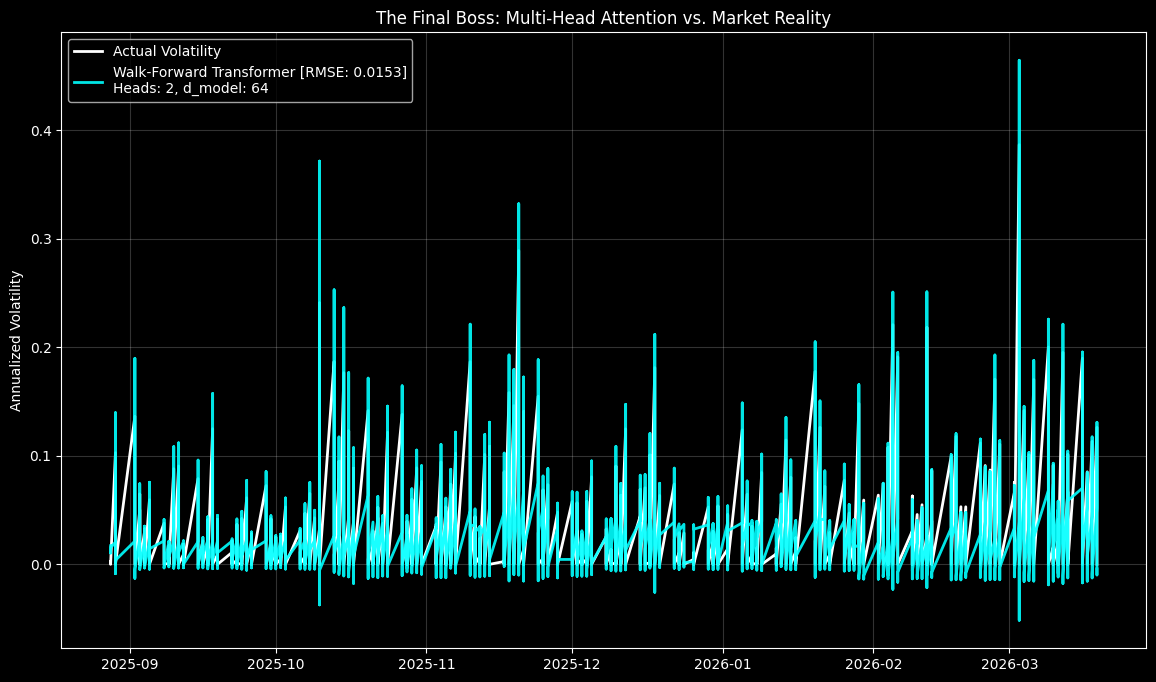

In [5]:
# 4. Plot the Carnage
plt.style.use('dark_background')
plt.figure(figsize=(14, 8))
plt.plot(dates, actual_vol, label="Actual Volatility", color='white', linewidth=2)
plt.plot(dates, wf_predictions, 
         label=f"Walk-Forward Transformer [RMSE: {wf_rmse:.4f}]\nHeads: {best_params['nhead']}, d_model: {best_params['d_model']}", 
         color='cyan', alpha=0.9, linewidth=2)

plt.title("The Final Boss: Multi-Head Attention vs. Market Reality")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.2)
plt.show()